# 02 - Rates

## Imports & data loading

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import ProjectConfig
from src.market.loaders import load_rate_curves
from src.rates.yield_curve import NelsonSiegelCurve, YieldCurve

In [3]:
cfg = ProjectConfig.default()

rate_curves = load_rate_curves(cfg.raw_rate_curves_path)

rate_curves.head()

,country,curve_tenor,curve_tenor_years,observation_date,rate_percent,rate_decimal
0,France,10Y,10.0,1986-01-02,9.989,0.09989
1,France,10Y,10.0,1986-01-03,9.993,0.09993
2,France,10Y,10.0,1986-01-06,9.997,0.09997
3,France,10Y,10.0,1986-01-07,10.002,0.10002
4,France,10Y,10.0,1986-01-08,10.006,0.10006


## Curve building

### Selection of one curve

In [4]:
observation_date = rate_curves["observation_date"].max()
country = rate_curves.loc[
    rate_curves["observation_date"] == observation_date,
    "country",
].iloc[0]

curve_data = rate_curves[
    (rate_curves["observation_date"] == observation_date)
    & (rate_curves["country"] == country)
].copy()

curve_data

,country,curve_tenor,curve_tenor_years,observation_date,rate_percent,rate_decimal
357968,United States,4M,0.333333,2026-02-25,3.695999,0.03696
357969,United States,6M,0.500000,2026-02-25,3.655,0.03655
357970,United States,1Y,1.000000,2026-02-25,3.532,0.03532
357971,United States,2Y,2.000000,2026-02-25,3.459,0.03459
357972,United States,3Y,3.000000,2026-02-25,3.466,0.03466
357973,United States,5Y,5.000000,2026-02-25,3.603,0.03603
357974,United States,7Y,7.000000,2026-02-25,3.799,0.03799
357975,United States,10Y,10.000000,2026-02-25,4.038,0.04038
357976,United States,20Y,20.000000,2026-02-25,4.632,0.04632
357977,United States,30Y,30.000000,2026-02-25,4.69,0.0469


### Building

In [5]:
linear_curve = YieldCurve.from_rate_curves(
    rate_curves,
    country=country,
    observation_date=observation_date,
    interpolation="linear",
)

cubic_curve = YieldCurve.from_rate_curves(
    rate_curves,
    country=country,
    observation_date=observation_date,
    interpolation="cubic",
)

nelson_siegel_curve = NelsonSiegelCurve.fit(
    linear_curve.maturities,
    linear_curve.zero_rates,
    name=f"Nelson-Siegel {country} {observation_date.date()}",
)

### Zero-rates

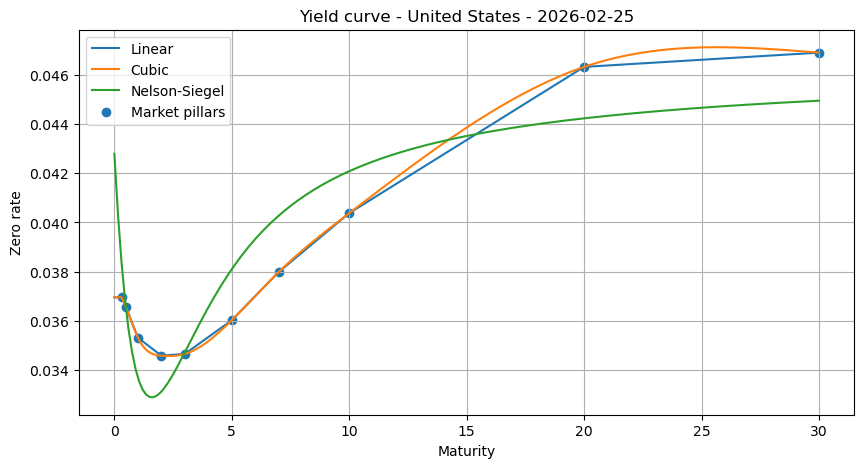

In [6]:
grid = np.linspace(0.0, linear_curve.maturities.max(), 200)

plt.figure(figsize=(10, 5))
plt.plot(grid, linear_curve.zero_rate(grid), label="Linear")
plt.plot(grid, cubic_curve.zero_rate(grid), label="Cubic")
plt.plot(grid, nelson_siegel_curve.zero_rate(grid), label="Nelson-Siegel")
plt.scatter(linear_curve.maturities, linear_curve.zero_rates, label="Market pillars")
plt.xlabel("Maturity")
plt.ylabel("Zero rate")
plt.title(f"Yield curve - {country} - {observation_date.date()}")
plt.legend()
plt.grid(True)
plt.show()

## Discount factors

In [7]:
df_frame = pd.DataFrame(
    {
        "maturity": grid,
        "df_linear": linear_curve.discount_factor(grid),
        "df_cubic": cubic_curve.discount_factor(grid),
        "df_nelson_siegel": nelson_siegel_curve.discount_factor(grid),
    }
)

df_frame.head()

,maturity,df_linear,df_cubic,df_nelson_siegel
0,0.000000,1.000000,1.000000,1.000000
1,0.150754,0.994444,0.994444,0.993934
2,0.301508,0.988918,0.988918,0.988485
3,0.452261,0.983553,0.983552,0.983464
4,0.603015,0.978350,0.978358,0.978726


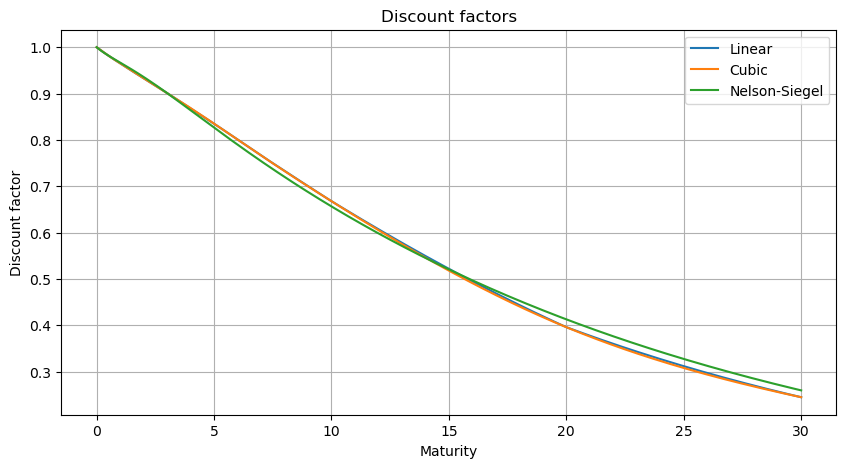

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df_frame["maturity"], df_frame["df_linear"], label="Linear")
plt.plot(df_frame["maturity"], df_frame["df_cubic"], label="Cubic")
plt.plot(df_frame["maturity"], df_frame["df_nelson_siegel"], label="Nelson-Siegel")
plt.xlabel("Maturity")
plt.ylabel("Discount factor")
plt.title("Discount factors")
plt.legend()
plt.grid(True)
plt.show()

## ZC pricing

In [9]:
notional = 100.0
maturity = 2.0

zc_prices = pd.DataFrame(
    {
        "method": ["linear", "cubic", "nelson_siegel"],
        "zero_rate": [
            linear_curve.zero_rate(maturity),
            cubic_curve.zero_rate(maturity),
            nelson_siegel_curve.zero_rate(maturity),
        ],
        "discount_factor": [
            linear_curve.discount_factor(maturity),
            cubic_curve.discount_factor(maturity),
            nelson_siegel_curve.discount_factor(maturity),
        ],
        "zero_coupon_price": [
            linear_curve.zero_coupon_price(maturity, notional=notional),
            cubic_curve.zero_coupon_price(maturity, notional=notional),
            nelson_siegel_curve.zero_coupon_price(maturity, notional=notional),
        ],
    }
)

zc_prices

,method,zero_rate,discount_factor,zero_coupon_price
0,linear,0.034590,0.933159,93.315870
1,cubic,0.034590,0.933159,93.315870
2,nelson_siegel,0.033129,0.935889,93.588933


## Forward rate

In [10]:
forward_examples = pd.DataFrame(
    {
        "start": [0.25, 1.0, 2.0],
        "end": [1.0, 2.0, 5.0],
    }
)

forward_examples["forward_linear"] = forward_examples.apply(
    lambda row: linear_curve.forward_rate(row["start"], row["end"]),
    axis=1,
)

forward_examples["forward_cubic"] = forward_examples.apply(
    lambda row: cubic_curve.forward_rate(row["start"], row["end"]),
    axis=1,
)

forward_examples["forward_nelson_siegel"] = forward_examples.apply(
    lambda row: nelson_siegel_curve.forward_rate(row["start"], row["end"]),
    axis=1,
)

forward_examples

,start,end,forward_linear,forward_cubic,forward_nelson_siegel
0,0.25,1.0,0.034773,0.034773,0.031930
1,1.00,2.0,0.033860,0.033860,0.032553
2,2.00,5.0,0.036990,0.036990,0.041421
